**N3c_analysis**: More in-depth analysis of the results obtained for a specific mask, with focus on the individual signal properties obtained. 

## 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
import satellite_RFI.src.tle_mapping as tle
import natsort
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm
from matplotlib.ticker import LogLocator, FormatStrFormatter


In [3]:
## ----- FITTING PARAMETERS ----- ##

# folder in which to save results
folder = "results/v6_results/"

# simulation information
path_beam = "{}satbeams_{}_{}_{}-{}.pkl".format(pm.folder, pm.block, pm.beam_model, *pm.freq_range)
path_catalog = f"{pm.folder}catalog_{pm.block}.csv"
path_nearby = f"{pm.folder}nearby_{pm.block}.pkl"
if path_catalog==f"{pm.folder}catalogOLD_{pm.block}.csv":  label_sats = "Sat"
else:  label_sats = "NORAD ID"

# cost function from eq. 11 (options: "C1"=radiometer, "C2"=1)
CF = "C1"

# angular mask [degrees] (options: 1,5 or None)
deg = None
if deg!=None:  times_nearby  = pickle.load(open(path_nearby, "rb"))[deg]
else:  times_nearby = None

# thermal mask [kelvin] (options: 25,50,100 or None)
temp = 100

# threshold pixel mask (options: 2,5,7 or None)
pix = None

# temporal mask [seconds] (options: 775-1000, 2200-2400, 5500-6200 or None)
time_slice = (None,None)


In [4]:
pm.show_parameters(CF, deg, temp, pix, time_slice)
print("")
print(f"Showing results from folder: {folder}")


Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: inf - inf seconds
The cost function denominator will be: radiometer equation (C1).
Masking: Thermal (100 K)

Showing results from folder: results/v6_results/


## 2. Set-up of global variables and functions

We start by initializing the simulation, and also the satellite listing that has additional information (such as the constellation, generation and name of a given satellite).

Getting catalog...
 - Number of signals in satellite catalog: 248 (initial), 131 (final).
Getting beam response...
 - Number of satellites present: 60
 - Size of sat_beam: 1.181 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 131
 - Size of Tb_factors: 0.001 GB
Getting observational data...
 - Size of observational data: 0.020 GB
 - Shape of observational data: (1199, 2204)


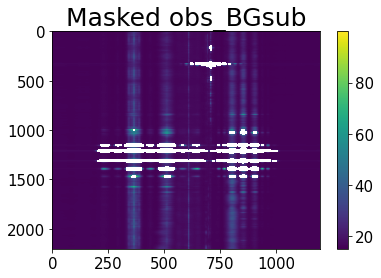

In [5]:
# initializing the simulation
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog=path_catalog,
    path_beam=path_beam,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=time_slice,
    label_sats=label_sats,
    verbose=True,
)

# getting observations and mask
sat.use_observations(path_observations=pm.path_observations, verbose=True)
sat.use_mask(times_nearby, temp, pix, apply=True, verbose=True)

# define some quantities
frequency = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
time = sat.time[sat.itime[0]:sat.itime[1]]


In [6]:
# getting alpha best-fit values
print("Getting best-fit values...")
fname = pm.my_name(folder, CF, deg, temp, pix, time_slice)
alphas = pickle.load( open(fname,"rb") )["best-fit"]

# getting the simulation
print("Simulating...")
sat.simulate(alphas)


Getting best-fit values...
Simulating...


In [7]:
# getting satellite info
satellites = pd.read_csv(pm.folder + "satellites.csv")
if label_sats=="Sat":  satellites.set_index(f"Name {pm.block}", inplace=True)
else:  satellites.set_index("NORAD ID", inplace=True)


## 3. Graphs for the total satellites and signals

We now define several different graphs that will check different properties of the best-fit simulation that was obtained. The first graphs represent the alphas obtained per signal (divided by constellation), the second graphs represent the power amplitude obtained per signal (includes P,G; divided by constellation), and the third graphs represent the simulated signal from each satellite compared to the total observations.

In [8]:
# --------------- plotting functions --------------- #

def plot_alphas(con, log=False):
    ''' Plot alphas of each signal for a given constellation. '''

    # creating figure
    fig, ax = plt.subplots(figsize=(9, 5))
    linestyles = ["-", "--", "-.", ":"]
    nulls = []

    for i,ID in enumerate(sat.sats):

        # geting name of satellite
        if label_sats=="Sat":  name = ID = tle.clean(ID)
        else:  name = satellites.loc[ID,f"Name {pm.block}"]
            
        # getting values
        if satellites.loc[ID,"Constellation"]!=con:  continue
        ys = alphas[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        xs = sat.catalog.loc[sat.catalog[label_sats]==ID,"Signal"]

        # if satellite has only null alphas, remove
        if np.abs(np.linalg.norm(ys))<1e-6:  
            nulls.append(name)
            continue

        #plotting the rest
        ys_plot = np.where(ys>0,ys,np.nan)
        if log:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)
        else:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=f"{name}")

        # plotting zero values
        idx0 = np.where(np.abs(ys)<1e-6)[0]
        if len(idx0):
            ax.plot(np.asarray(xs)[idx0], np.full(len(idx0), ax.get_ylim()[0]), "x",
                    color=ax.lines[-1].get_color(), ms=8)

    # showing figure
    if log:  
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_ylabel('Amplitude')
    ax.set_xlabel(r'Signal $[\alpha_{i}]$')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.set_title(f"Alphas for {con}")
    fig.tight_layout()
    plt.show()
    print(f"Satellites with only null alphas: {nulls}")


# -------------------------------------------------- #

def plot_power(con, log=False):
    ''' Plot alphas of each signal for a given constellation. '''

    # creating figure
    fig, ax = plt.subplots(figsize=(9, 5))
    linestyles = ["-", "--", "-.", ":"]
    nulls = []

    for i,ID in enumerate(sat.sats):

        # geting name of satellite
        if label_sats=="Sat":  name = ID = tle.clean(ID)
        else:  name = satellites.loc[ID,f"Name {pm.block}"]
        
        # getting values
        if satellites.loc[ID,"Constellation"]!=con:  continue
        Ps = np.array(sat.catalog["P(dBW)"])[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        Gs = np.array(sat.catalog["G(dBi)"])[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        ys = alphas[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]] * 10**(Ps/10 + Gs/10)
        xs = sat.catalog.loc[sat.catalog[label_sats]==ID,"Signal"]

        # if satellite has only null alphas, remove
        if np.abs(np.linalg.norm(ys))<1e-6:  
            nulls.append(name)
            continue

        #plotting the rest
        ys_plot = np.where(ys>0,ys,np.nan)
        if log:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)
        else:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=f"{name}")

        # plotting zero values
        idx0 = np.where(np.abs(ys)<1e-6)[0]
        if len(idx0):
            ax.plot(np.asarray(xs)[idx0], np.full(len(idx0), ax.get_ylim()[0]), "x",
                    color=ax.lines[-1].get_color(), ms=8)

    # showing figure
    if log:  
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_ylabel(r'Power $[\alpha_{i} \times 10^{P/10 + G/10}]$')
    ax.set_xlabel(r'Signal $[\alpha_{i}]$')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.set_title(f"Power for {con}")
    fig.tight_layout()
    plt.show()
    print(f"Satellites with only null alphas: {nulls}")


# -------------------------------------------------- #

def plot_1d(con):
    ''' Plot 1d map of the contribution of each satellite in frequency and time. '''

    # satellites with null alphas get removed
    nulls = []

    for i,ID in enumerate(sat.sats):

        # geting name of satellite
        if label_sats=="Sat":  name = ID = tle.clean(ID)
        else:  name = satellites.loc[ID,f"Name {pm.block}"]        
        # if alphas are null or satellite is not in cons, remove
        ind_i = sat.index_sats[i]
        ind_e = sat.n_signals[i]
        if satellites.loc[ID,"Constellation"]!=con:  continue
        if np.abs(np.linalg.norm(alphas[ind_i : ind_i+ind_e]))<1e-6:  
            nulls.append(name)
            continue

        # calculating contribution
        sim_i = np.zeros_like(sat.obs)
        for j in range(ind_i, ind_i+ind_e):
            sim_i += sat.sat_beam[i] * sat.Tb_factors[j][:,None] * alphas[j]
        
        # plotting figure
        fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=False, sharey=False)
        axis = [frequency,time]
        label = ["Frequency (MHz)", "Time (s)"]
        for j,ax in enumerate(axs):
            ax.plot(axis[j], np.ma.mean(sat.obs_BGsub.T, axis=j), label="Observation")
            ax.plot(axis[j], np.ma.mean(sim_i.T,axis=j), "--", label="Simulation")
            ax.set_xlabel(label[j])
            ax.set_ylabel('Temperature (K)')
            ax.legend(loc="upper left")
            #ax.set_yscale("log")
        fig.suptitle(f"Satellite {name}")
        fig.tight_layout()
        plt.show()
        
    print(f"Satellites with only null alphas: {nulls}")


# -------------------------------------------------- #

def plot_2d(con):
    ''' Plot 2d map of the contribution of each satellite. '''

    # satellites with null alphas get removed
    nulls = []

    for i,ID in enumerate(sat.sats):

        # geting name of satellite
        if label_sats=="Sat":  name = ID = tle.clean(ID)
        else:  name = satellites.loc[ID,f"Name {pm.block}"]
        
        # if alphas are null or satellite is not in cons, remove
        ind_i = sat.index_sats[i]
        ind_e = sat.n_signals[i]
        if satellites.loc[ID,"Constellation"]!=con:  continue
        if np.abs(np.linalg.norm(alphas[ind_i : ind_i+ind_e]))<1e-6:  
            nulls.append(name)
            continue

        # calculating contribution
        sim_i = np.zeros_like(sat.obs)
        for j in range(ind_i, ind_i+ind_e):
            sim_i += sat.sat_beam[i] * sat.Tb_factors[j][:,None] * alphas[j]
        
        # creating figures
        fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
        titles = ["Observation", name, "Residuals"]
        datas = [np.ma.masked_equal(sat.obs_BGsub.T,0) + sat.BG.T, 
                 np.ma.masked_equal(sim_i.T,0) + sat.BG.T,
                 np.ma.masked_equal(sat.obs_BGsub.T - sim_i.T,0)]
        
        for i,data in enumerate(datas):
            # plotting values
            ax = axs[i]
            cax = ax.imshow(data, aspect='auto', extent=[frequency[0], frequency[-1], time[-1], time[0]])
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(titles[i])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')
    
        # showing figure
        fig.tight_layout()
        plt.show()
        
    print(f"Satellites with only null alphas: {nulls}")


# -------------------------------------------------- #

def plot_integrated_signals(con, log=False):
    ''' Plot simulated signal of each satellite integrated in 
    time and frequency for a given constellation. '''

    # creating figure
    fig, ax = plt.subplots(figsize=(9, 5))
    linestyles = ["-", "--", "-.", ":"]
    nulls = []

    for i,ID in enumerate(sat.sats):

        # geting name of satellite
        if label_sats=="Sat":  name = ID = tle.clean(ID)
        else:  name = satellites.loc[ID,f"Name {pm.block}"]
        
        # getting values
        ind_i = sat.index_sats[i]
        ind_e = sat.n_signals[i]
        ys = alphas[ind_i: ind_i+ind_e]
        xs = sat.catalog.loc[sat.catalog[label_sats]==ID,"Signal"]

        # removing if necessary
        if satellites.loc[ID,"Constellation"]!=con:  continue
        if np.abs(np.linalg.norm(ys))<1e-6:  
            nulls.append(name)
            continue

        # calculating integrated signals
        ys_plot = np.zeros_like(ys)
        sim_i = np.zeros_like(sat.obs)
        for n,j in enumerate(range(ind_i, ind_i+ind_e)):
            ys_plot[n] = np.mean(sat.sat_beam[i] * sat.Tb_factors[j][:,None] * alphas[j])
        ys_plot = np.where(ys_plot>0,ys_plot,np.nan)

        #plotting the rest
        if log:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)
        else:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)

        # plotting zero values
        idx0 = np.where(np.abs(ys)<1e-6)[0]
        if len(idx0):
            ax.plot(np.asarray(xs)[idx0], np.full(len(idx0), ax.get_ylim()[0]), "x",
                    color=ax.lines[-1].get_color(), ms=8)

    # showing figure
    if log:  
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_ylabel('Integrated signal power')
    ax.set_xlabel(r'Signal $[\alpha_{i}]$')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.set_title(f"Contributions for {con}")
    fig.tight_layout()
    plt.show()
    print(f"Satellites with only null alphas: {nulls}")


# -------------------------------------------------- #


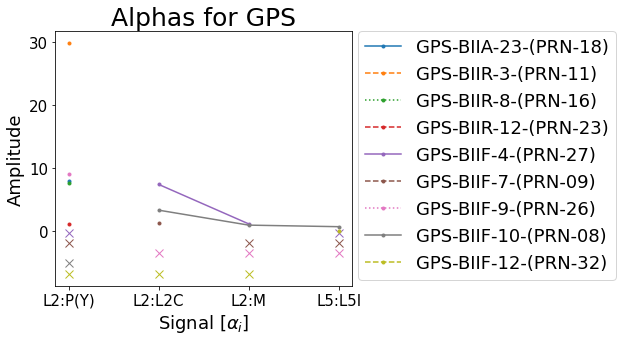

Satellites with only null alphas: ['GPS-BIIR-6-(PRN-14)', 'GPS-BIIR-10-(PRN-22)', 'GPS-BIIRM-2-(PRN-31)', 'GPS-BIIRM-6-(PRN-07)', 'GPS-BIIF-8-(PRN-03)']


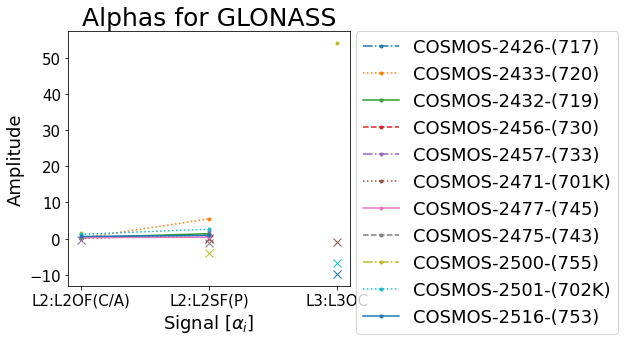

Satellites with only null alphas: []


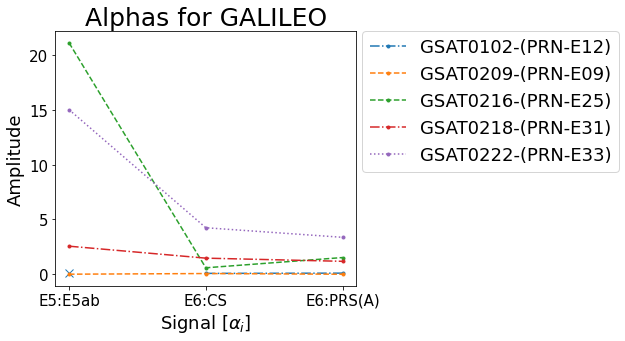

Satellites with only null alphas: ['GSAT0101-(PRN-E11)', 'GSAT0201-(PRN-E18)', 'GSAT0205-(PRN-E24)', 'GSAT0212-(PRN-E03)', 'GSAT0213-(PRN-E04)', 'GSAT0214-(PRN-E05)']


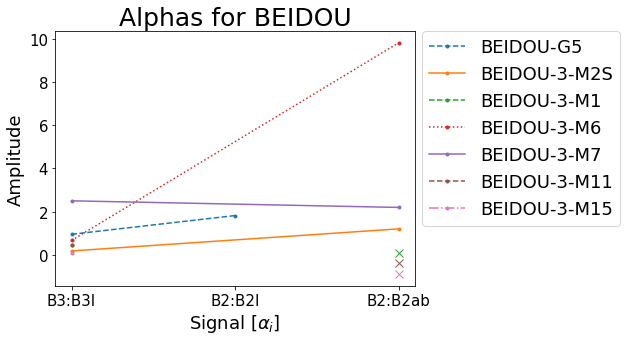

Satellites with only null alphas: ['BEIDOU-G3', 'BEIDOU-M4', 'BEIDOU-M6', 'BEIDOU-3-M5', 'BEIDOU-3-M17']


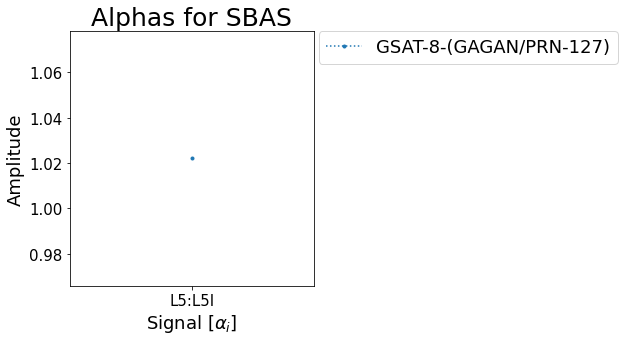

Satellites with only null alphas: ['AOR-E-(EGNOS/PRN-120)', 'IOR-W-(EGNOS/PRN-126)', 'SES-5-(EGNOS/PRN-136)', 'GSAT-10-(GAGAN/PRN-128)', 'LUCH-5B-(SDCM/PRN-125)', 'ASTRA-5B-(EGNOS/PRN-123)']


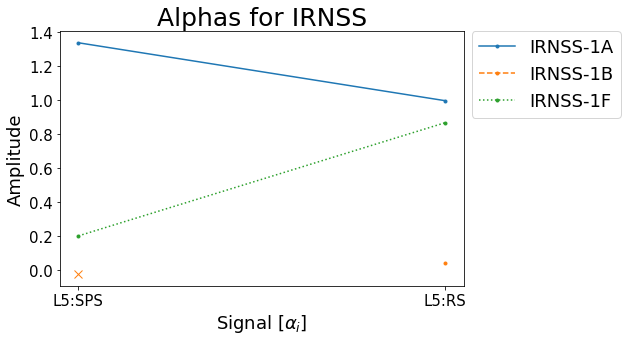

Satellites with only null alphas: ['IRNSS-1C', 'IRNSS-1I']


In [9]:
# plotting alphas
cons = ["GPS","GLONASS","GALILEO","BEIDOU","SBAS","IRNSS"]
for con in cons:
    plot_alphas(con,log=False)


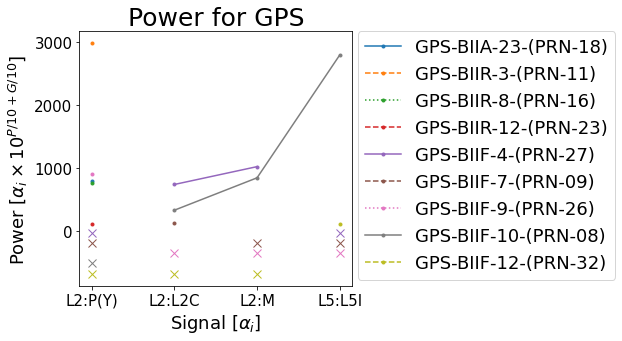

Satellites with only null alphas: ['GPS-BIIR-6-(PRN-14)', 'GPS-BIIR-10-(PRN-22)', 'GPS-BIIRM-2-(PRN-31)', 'GPS-BIIRM-6-(PRN-07)', 'GPS-BIIF-8-(PRN-03)']


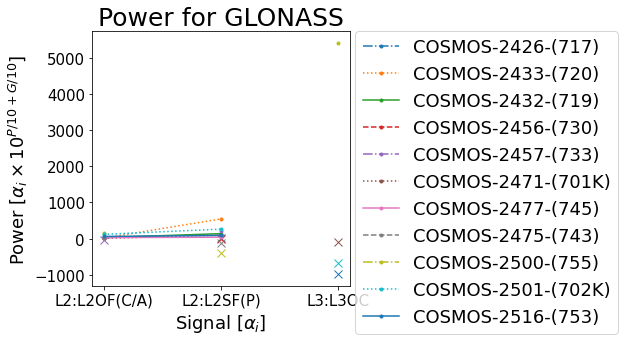

Satellites with only null alphas: []


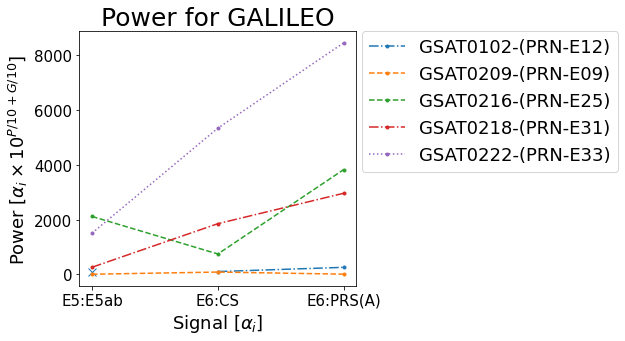

Satellites with only null alphas: ['GSAT0101-(PRN-E11)', 'GSAT0201-(PRN-E18)', 'GSAT0205-(PRN-E24)', 'GSAT0212-(PRN-E03)', 'GSAT0213-(PRN-E04)', 'GSAT0214-(PRN-E05)']


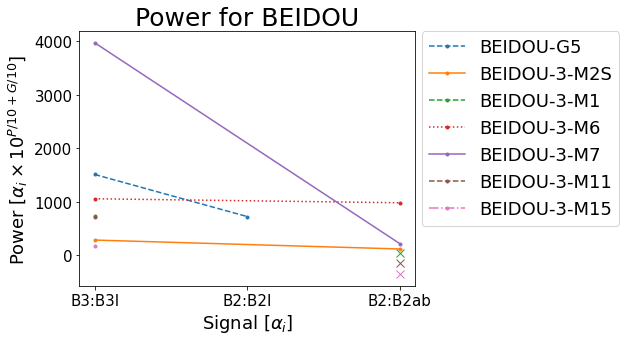

Satellites with only null alphas: ['BEIDOU-G3', 'BEIDOU-M4', 'BEIDOU-M6', 'BEIDOU-3-M5', 'BEIDOU-3-M17']


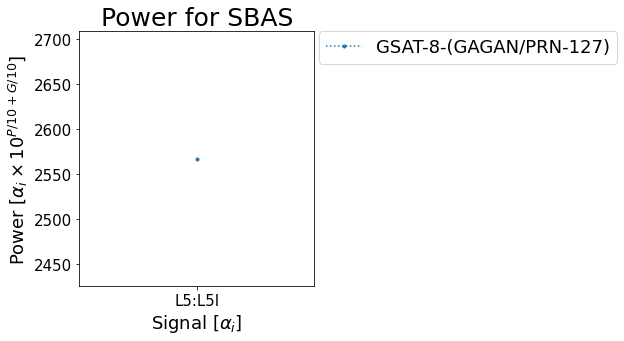

Satellites with only null alphas: ['AOR-E-(EGNOS/PRN-120)', 'IOR-W-(EGNOS/PRN-126)', 'SES-5-(EGNOS/PRN-136)', 'GSAT-10-(GAGAN/PRN-128)', 'LUCH-5B-(SDCM/PRN-125)', 'ASTRA-5B-(EGNOS/PRN-123)']


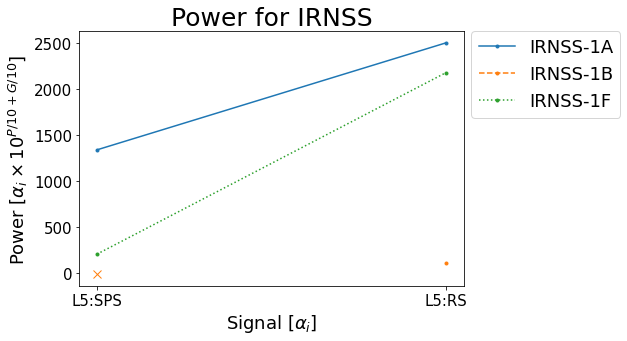

Satellites with only null alphas: ['IRNSS-1C', 'IRNSS-1I']


In [10]:
# plotting power
for con in cons:
    plot_power(con,log=False)


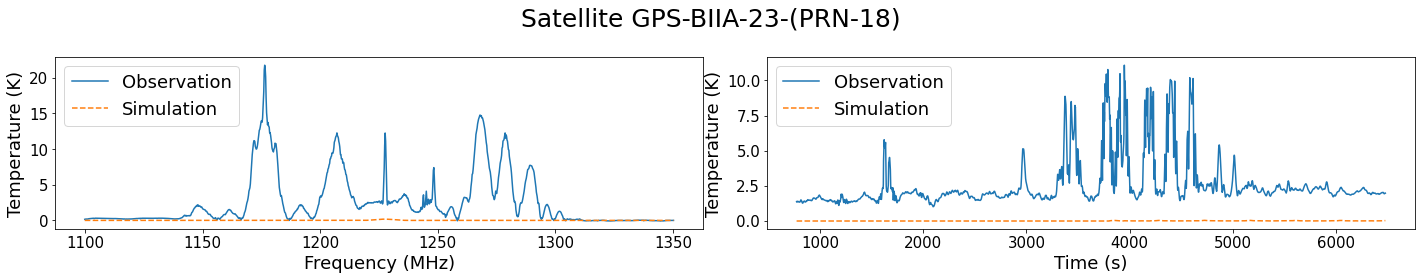

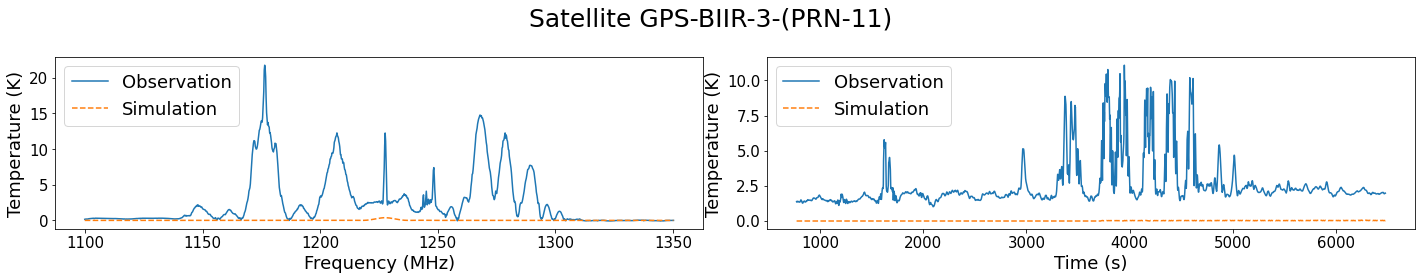

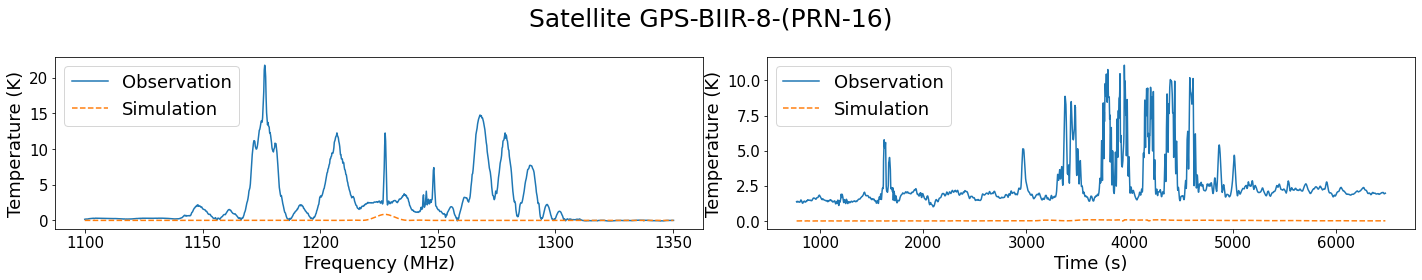

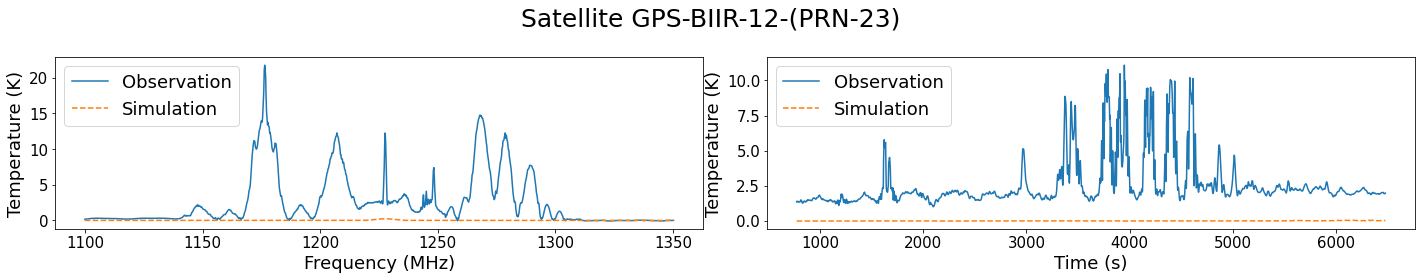

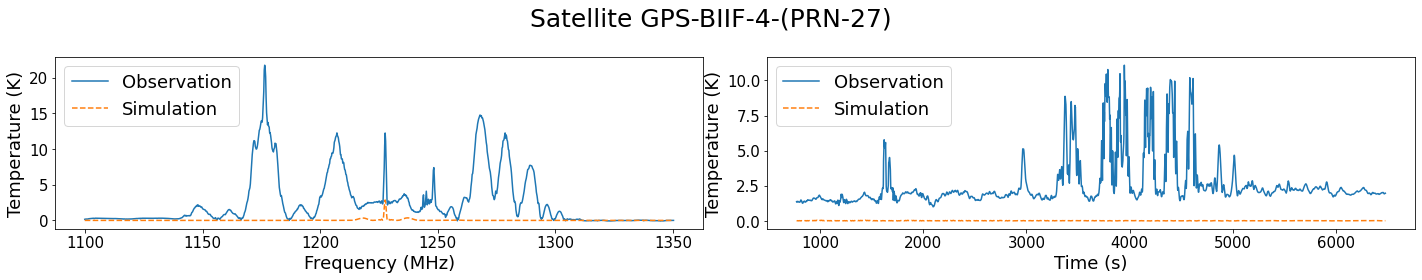

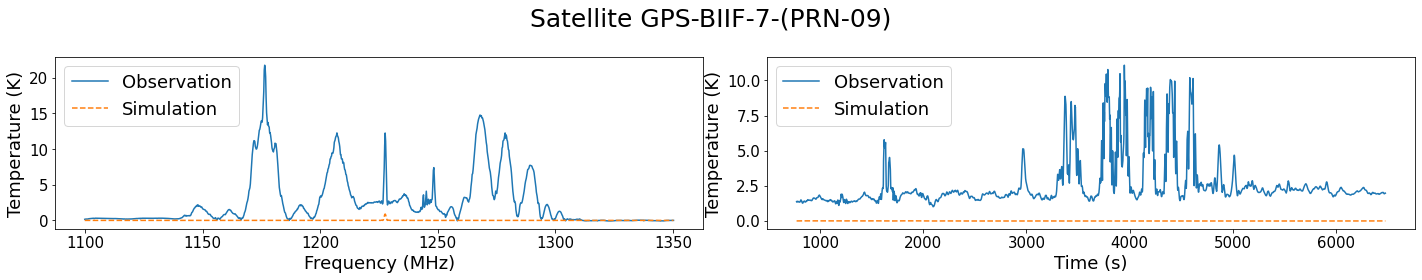

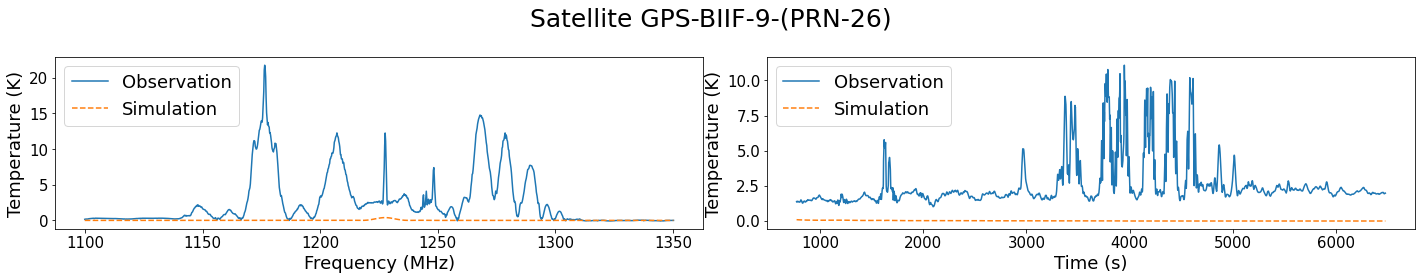

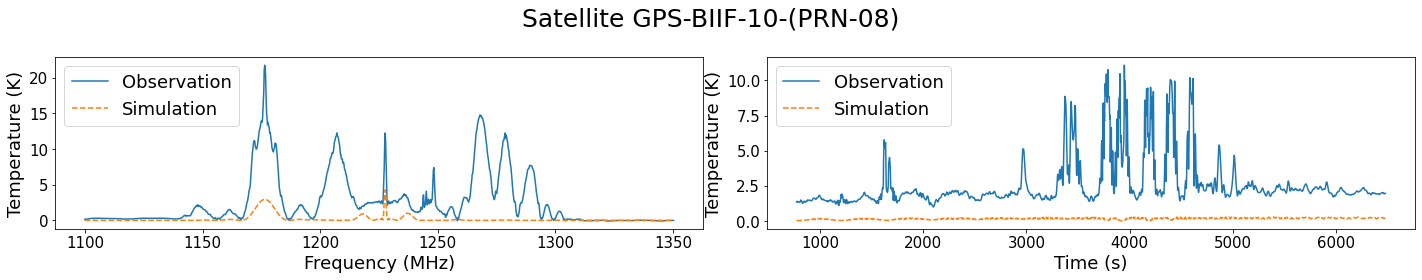

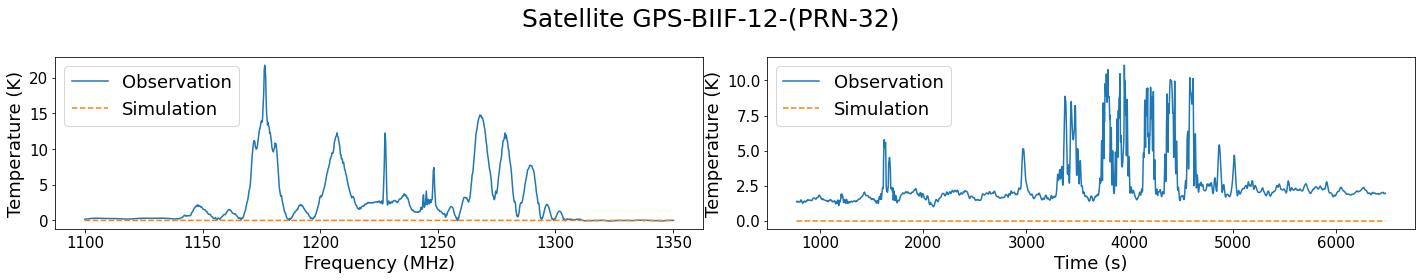

Satellites with only null alphas: ['GPS-BIIR-6-(PRN-14)', 'GPS-BIIR-10-(PRN-22)', 'GPS-BIIRM-2-(PRN-31)', 'GPS-BIIRM-6-(PRN-07)', 'GPS-BIIF-8-(PRN-03)']


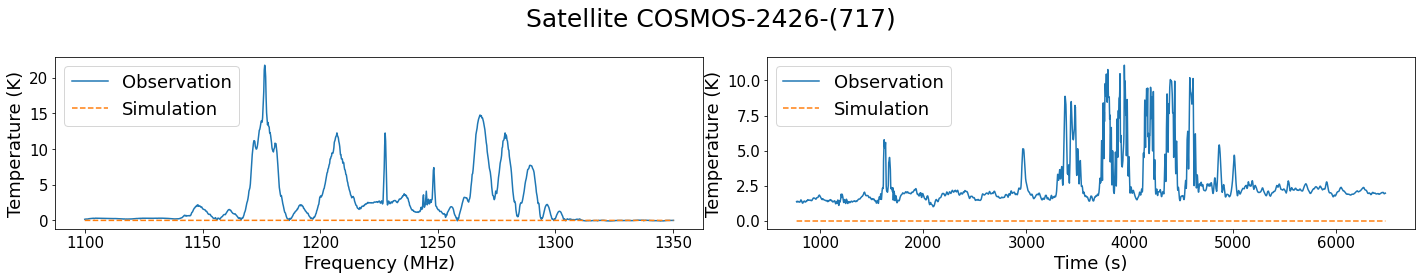

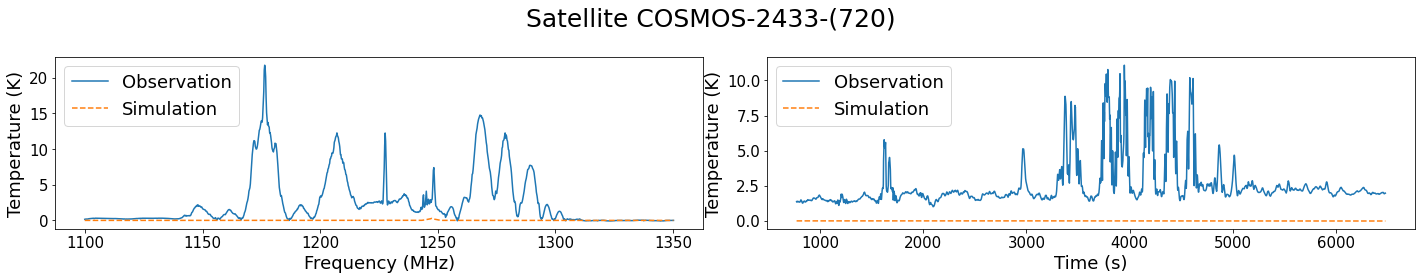

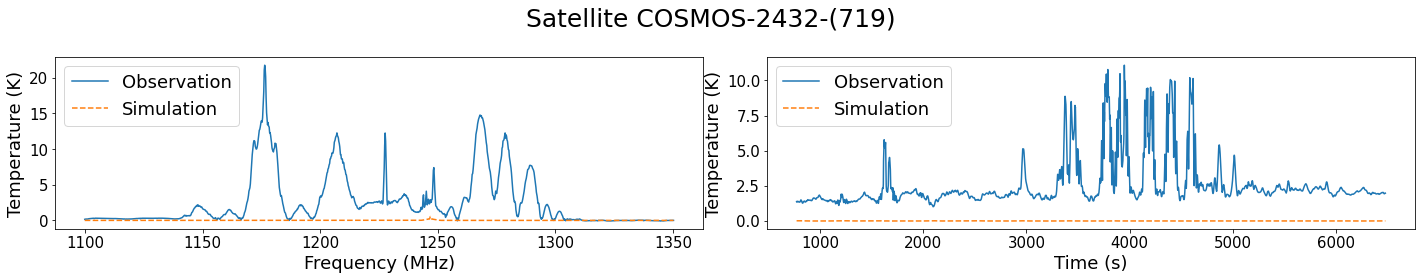

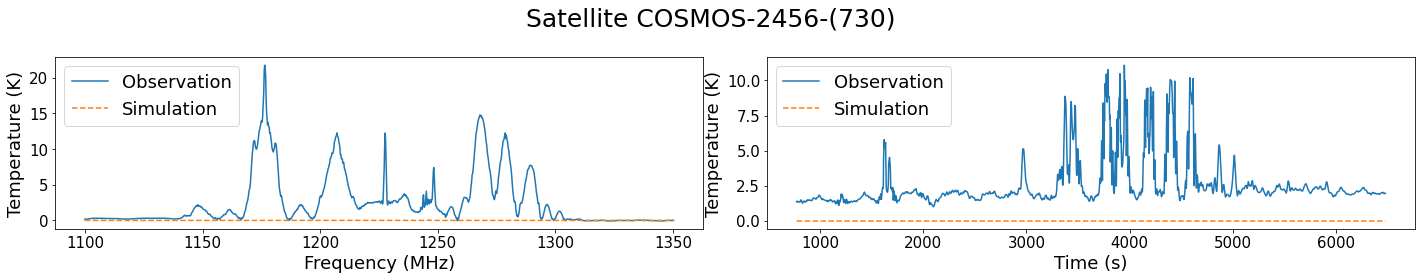

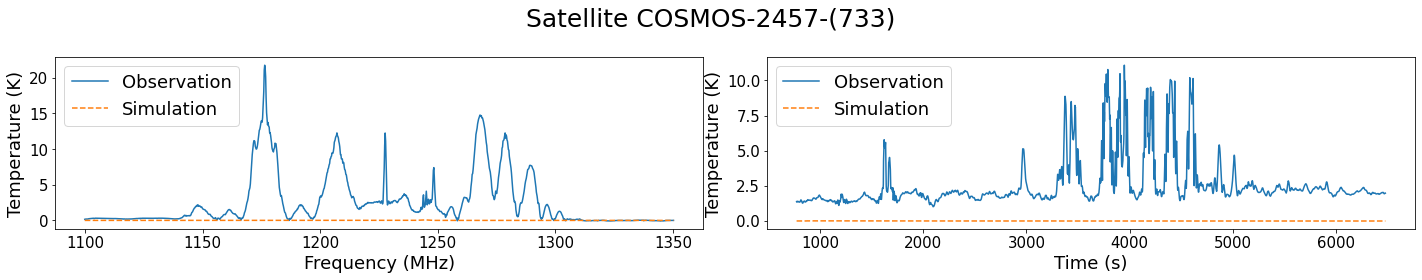

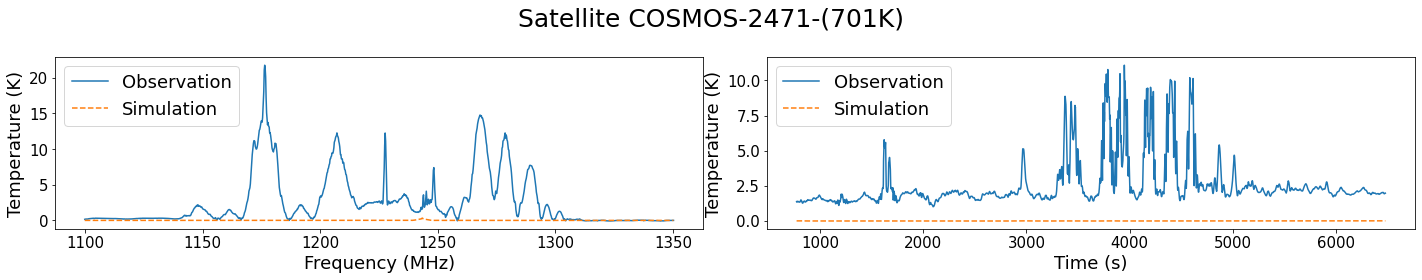

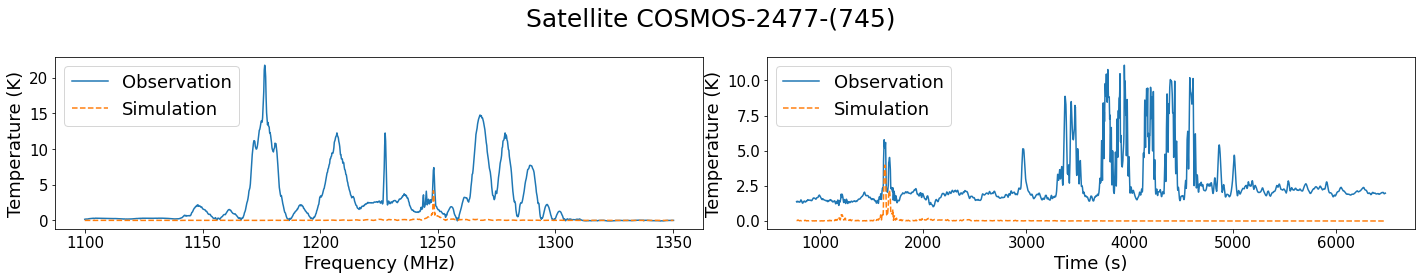

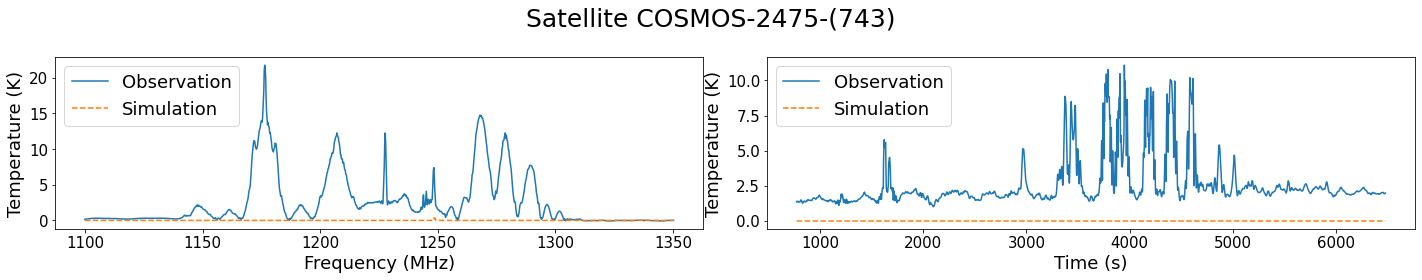

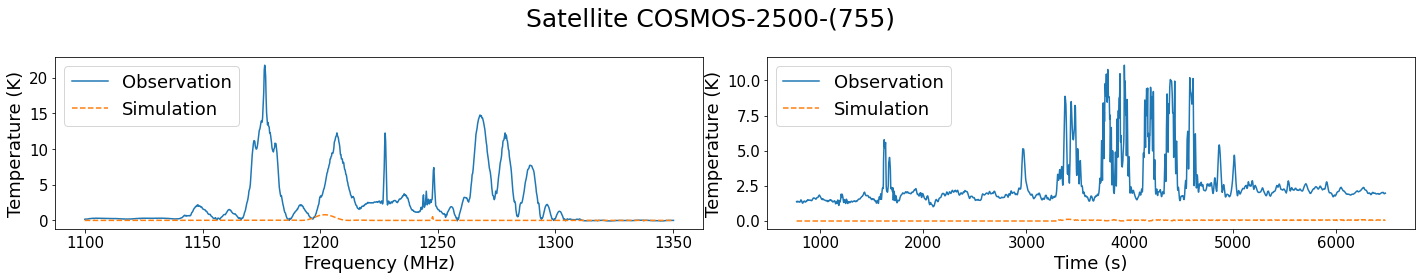

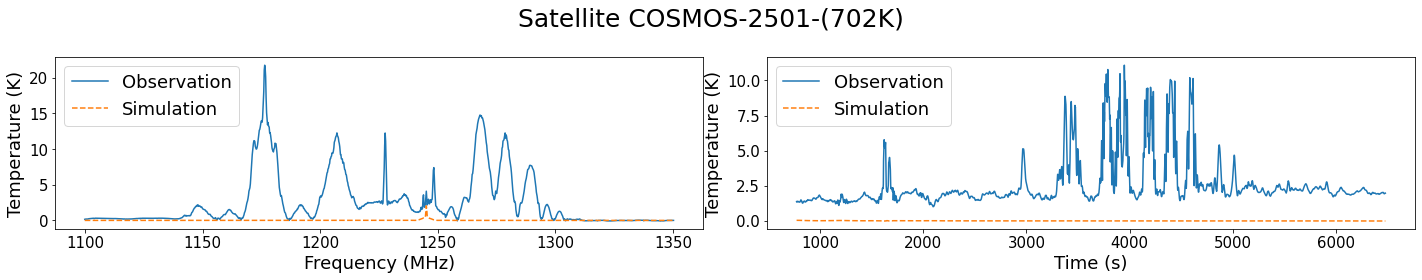

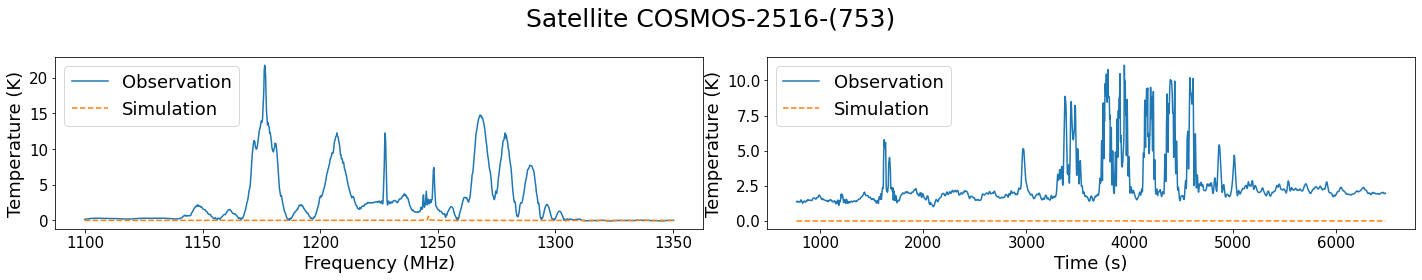

Satellites with only null alphas: []


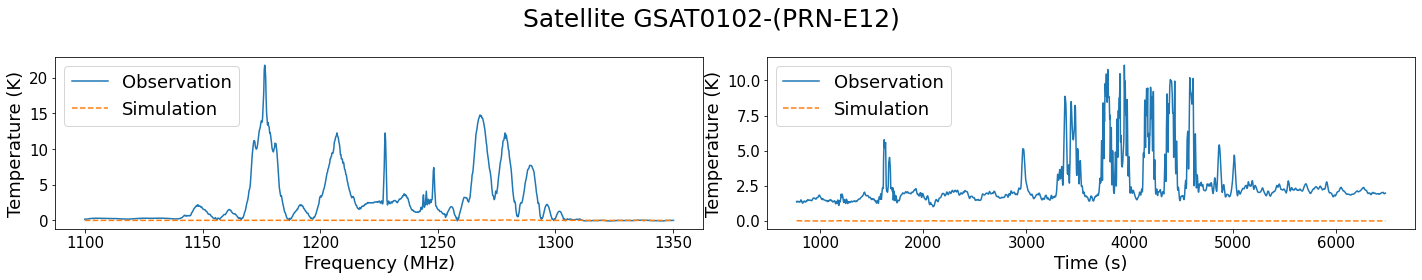

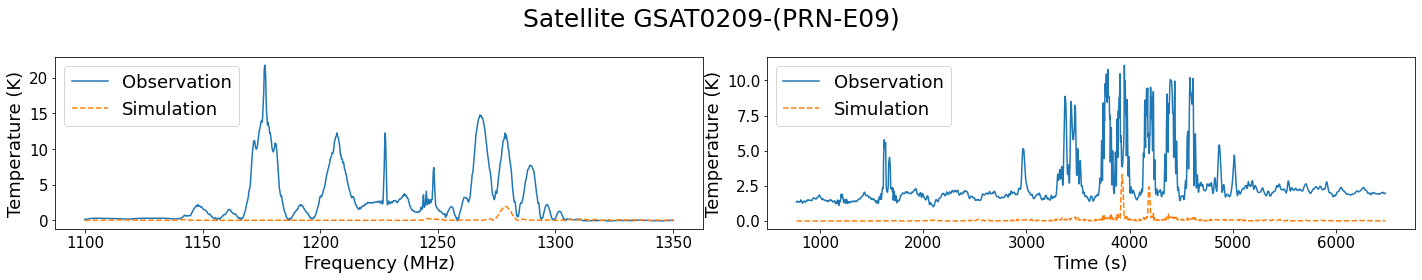

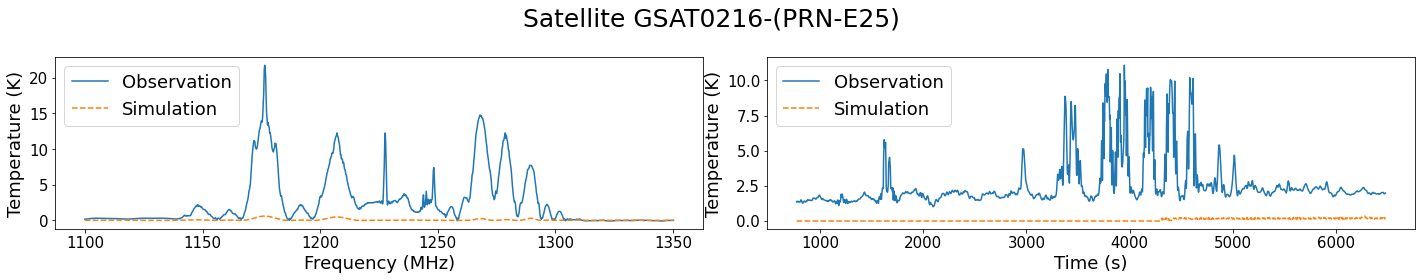

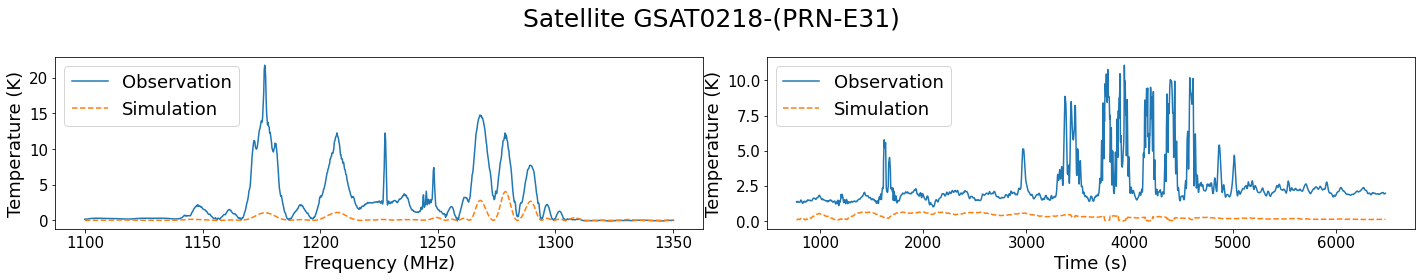

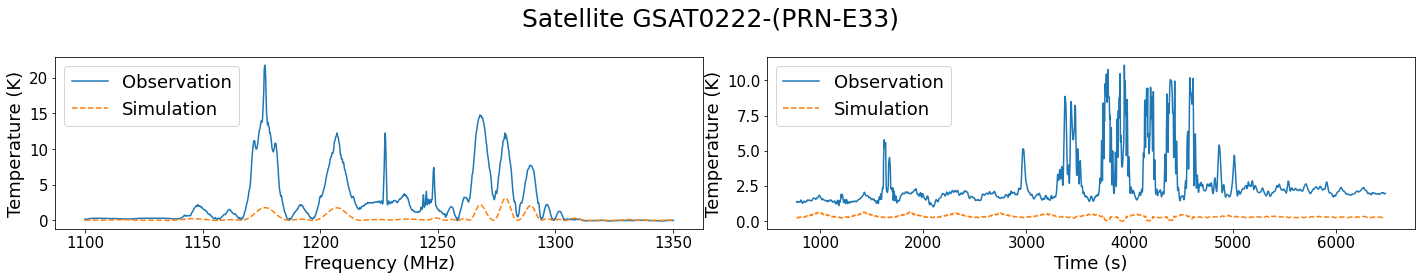

Satellites with only null alphas: ['GSAT0101-(PRN-E11)', 'GSAT0201-(PRN-E18)', 'GSAT0205-(PRN-E24)', 'GSAT0212-(PRN-E03)', 'GSAT0213-(PRN-E04)', 'GSAT0214-(PRN-E05)']


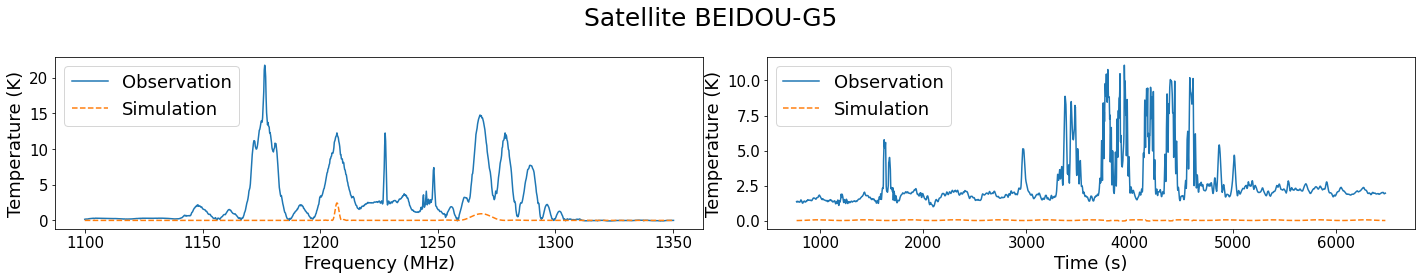

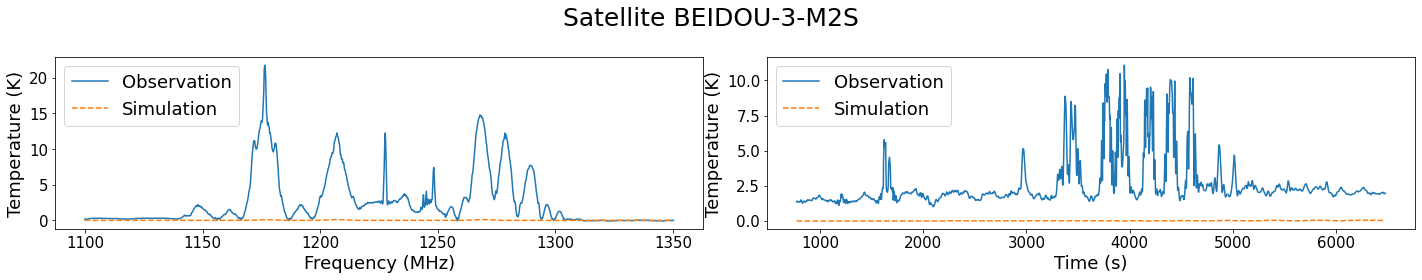

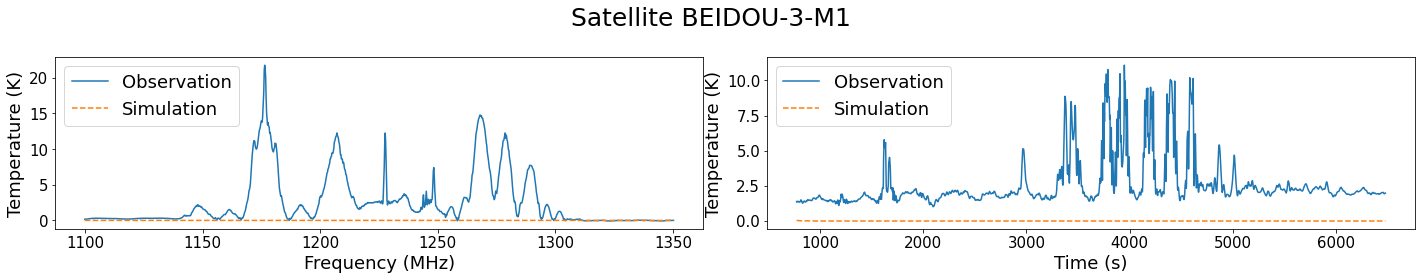

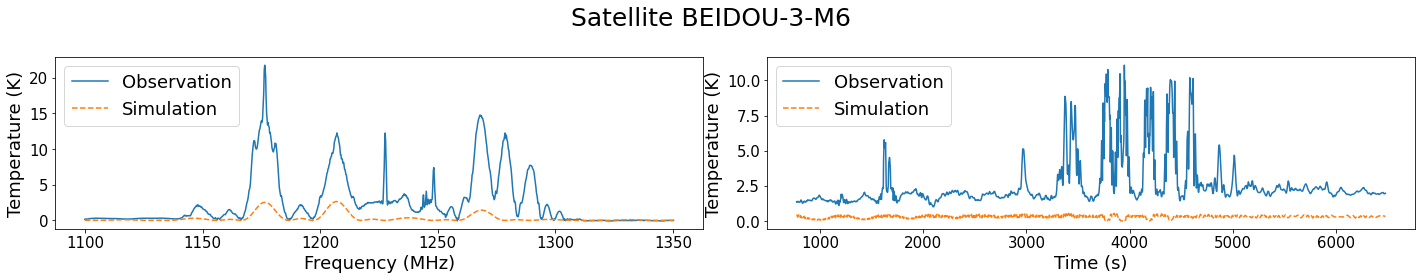

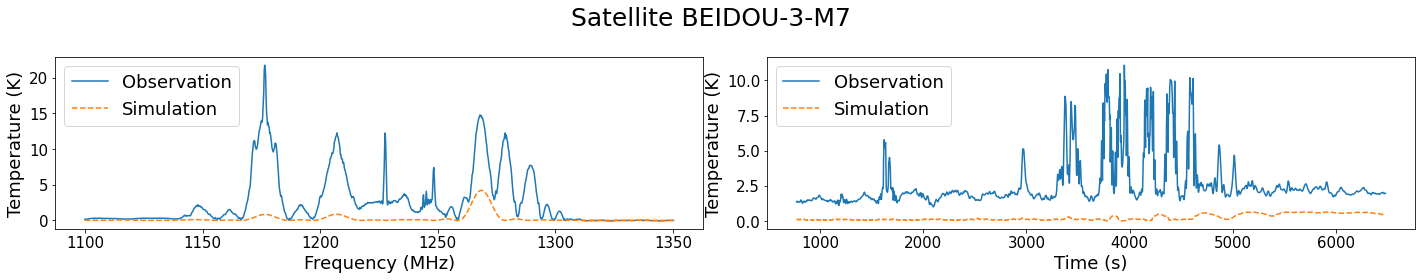

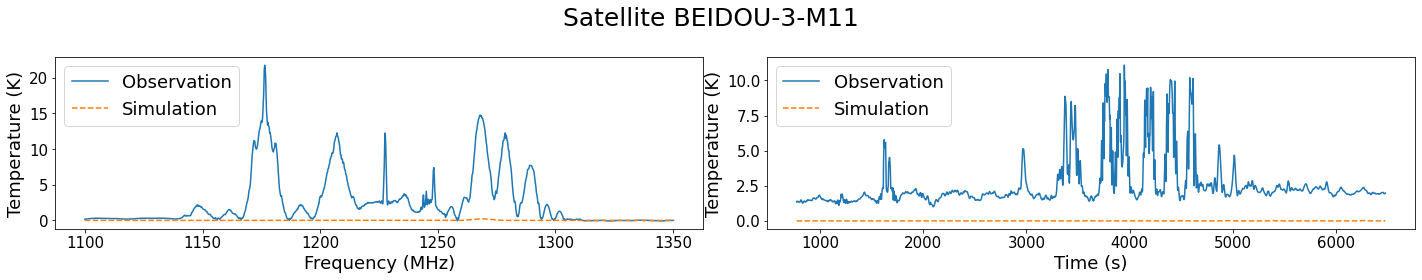

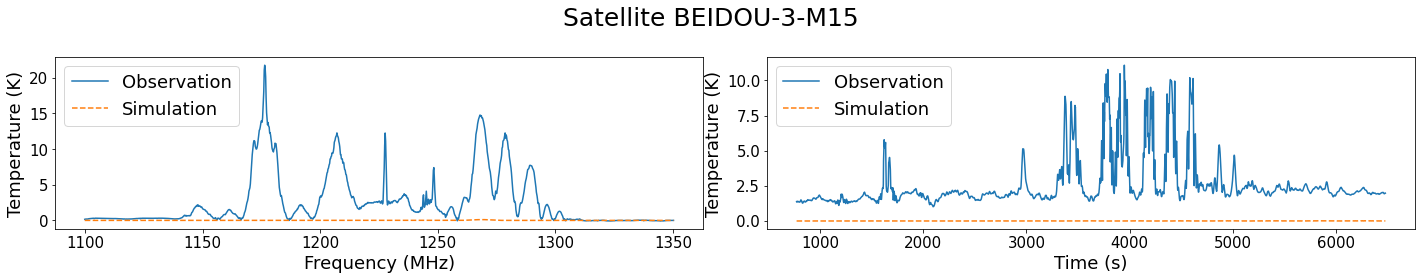

Satellites with only null alphas: ['BEIDOU-G3', 'BEIDOU-M4', 'BEIDOU-M6', 'BEIDOU-3-M5', 'BEIDOU-3-M17']


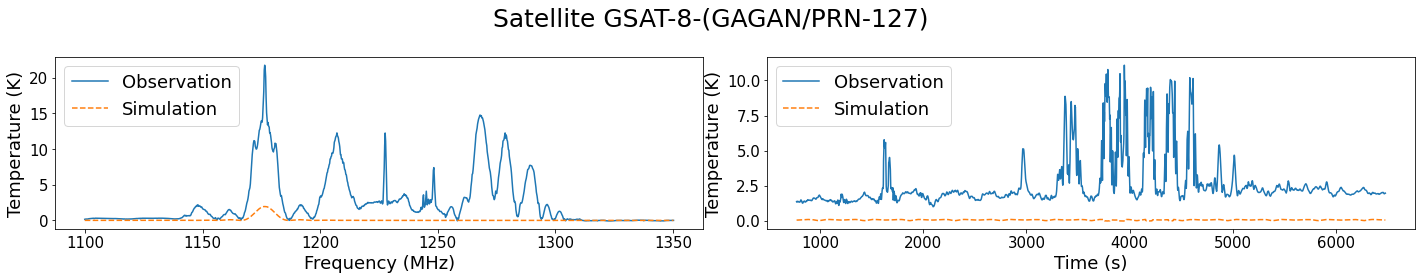

Satellites with only null alphas: ['AOR-E-(EGNOS/PRN-120)', 'IOR-W-(EGNOS/PRN-126)', 'SES-5-(EGNOS/PRN-136)', 'GSAT-10-(GAGAN/PRN-128)', 'LUCH-5B-(SDCM/PRN-125)', 'ASTRA-5B-(EGNOS/PRN-123)']


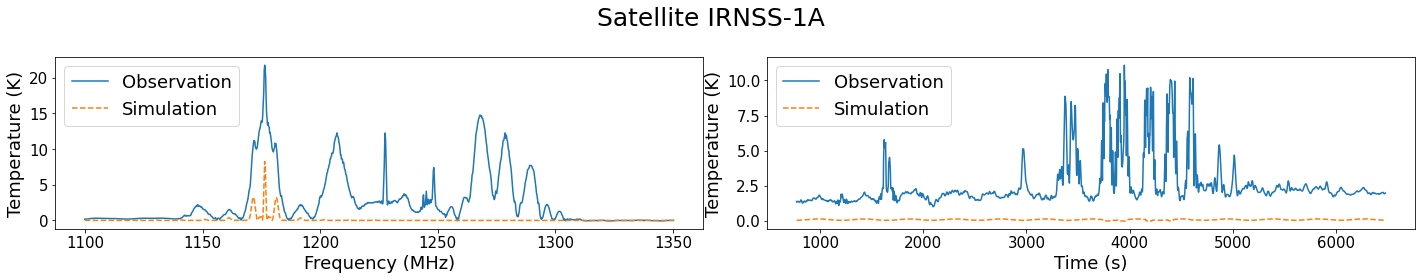

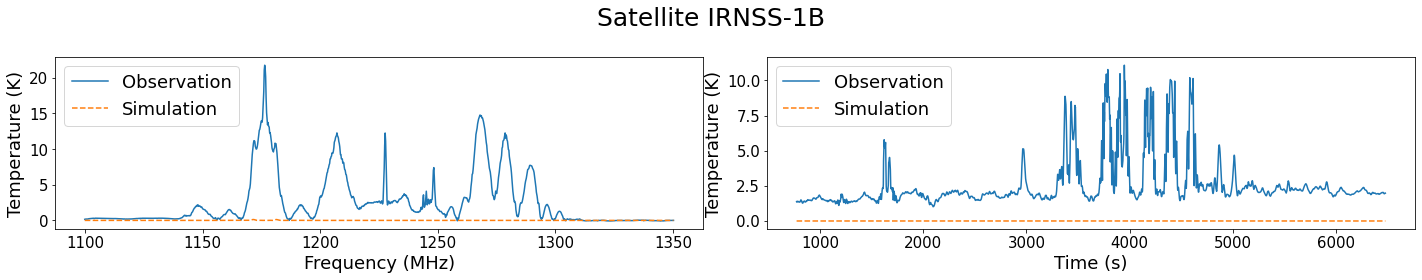

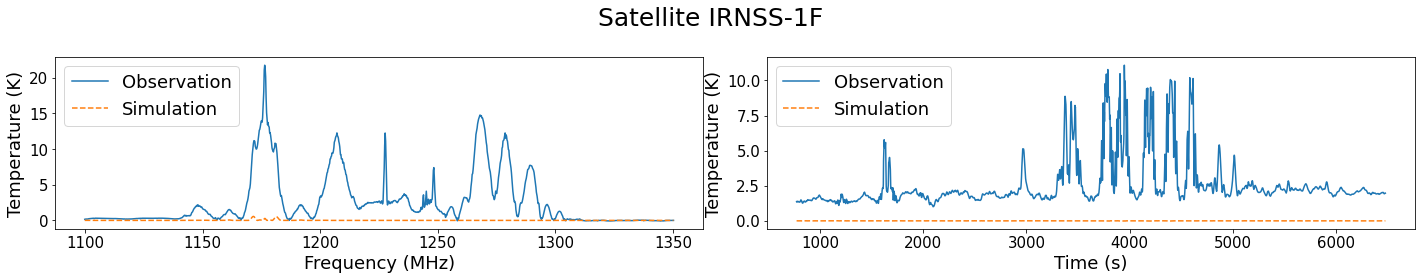

Satellites with only null alphas: ['IRNSS-1C', 'IRNSS-1I']


In [11]:
# plotting simulated signal summed in frequency and time
for con in cons:
    plot_1d(con)


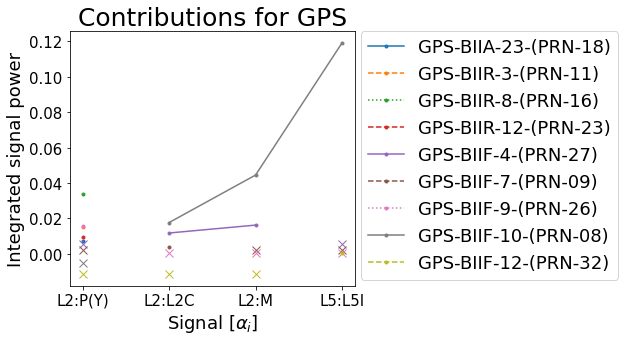

Satellites with only null alphas: ['GPS-BIIR-6-(PRN-14)', 'GPS-BIIR-10-(PRN-22)', 'GPS-BIIRM-2-(PRN-31)', 'GPS-BIIRM-6-(PRN-07)', 'GPS-BIIF-8-(PRN-03)']


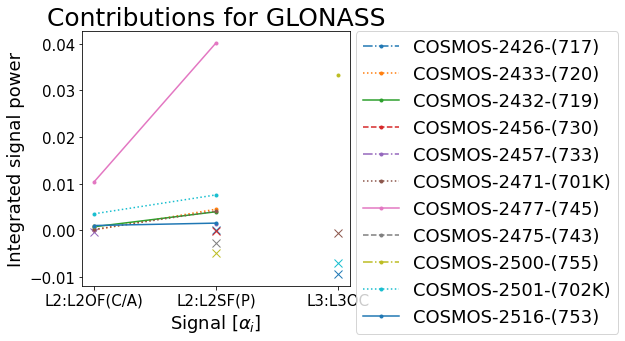

Satellites with only null alphas: []


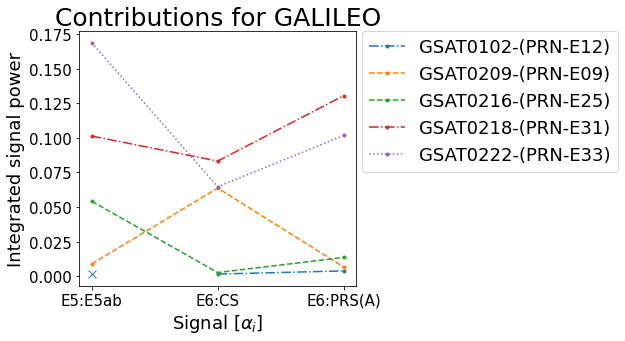

Satellites with only null alphas: ['GSAT0101-(PRN-E11)', 'GSAT0201-(PRN-E18)', 'GSAT0205-(PRN-E24)', 'GSAT0212-(PRN-E03)', 'GSAT0213-(PRN-E04)', 'GSAT0214-(PRN-E05)']


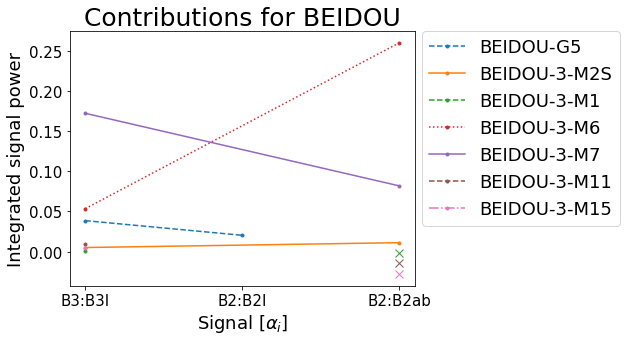

Satellites with only null alphas: ['BEIDOU-G3', 'BEIDOU-M4', 'BEIDOU-M6', 'BEIDOU-3-M5', 'BEIDOU-3-M17']


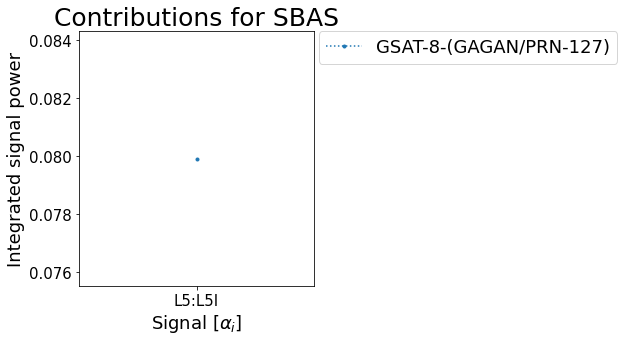

Satellites with only null alphas: ['AOR-E-(EGNOS/PRN-120)', 'IOR-W-(EGNOS/PRN-126)', 'SES-5-(EGNOS/PRN-136)', 'GSAT-10-(GAGAN/PRN-128)', 'LUCH-5B-(SDCM/PRN-125)', 'ASTRA-5B-(EGNOS/PRN-123)']


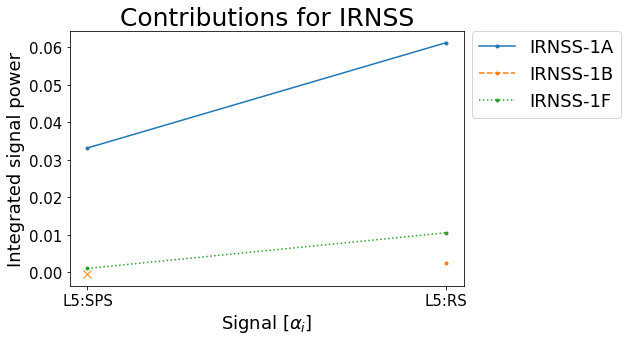

Satellites with only null alphas: ['IRNSS-1C', 'IRNSS-1I']


In [12]:
# plotting total integrated power for each signal
for con in cons:
    plot_integrated_signals(con, log=False)


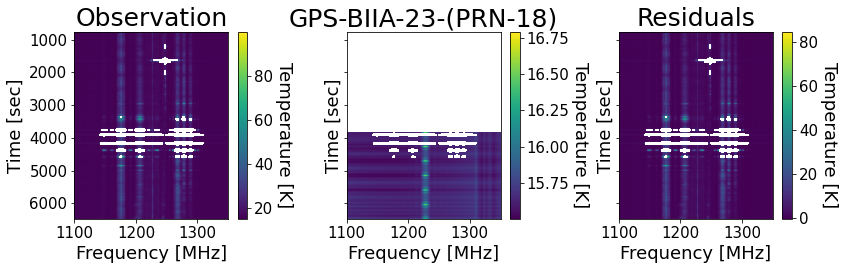

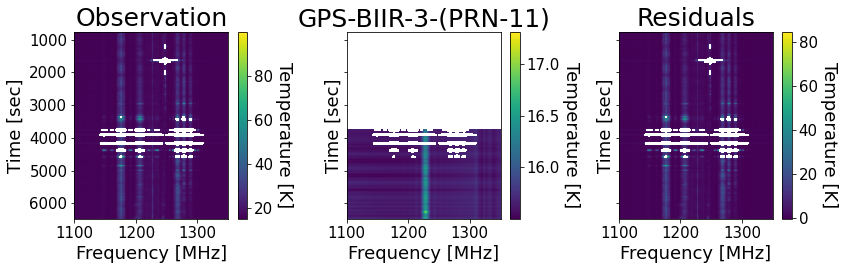

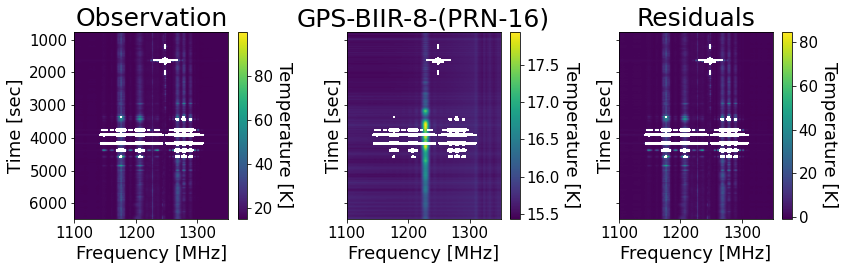

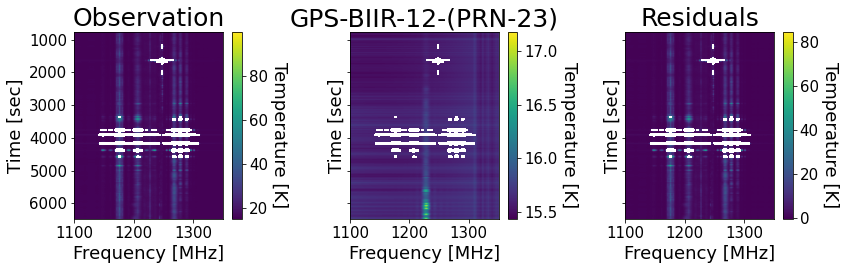

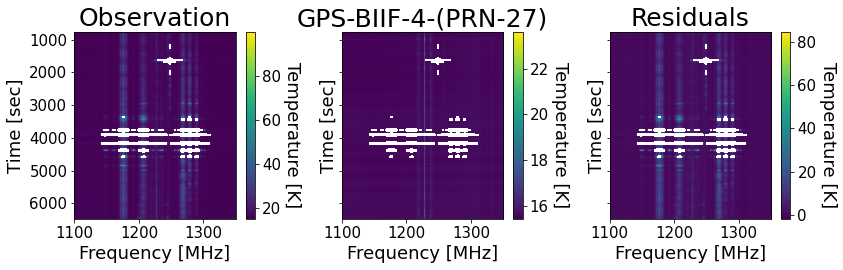

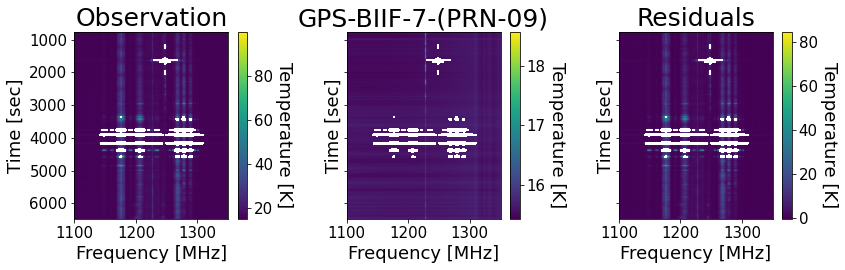

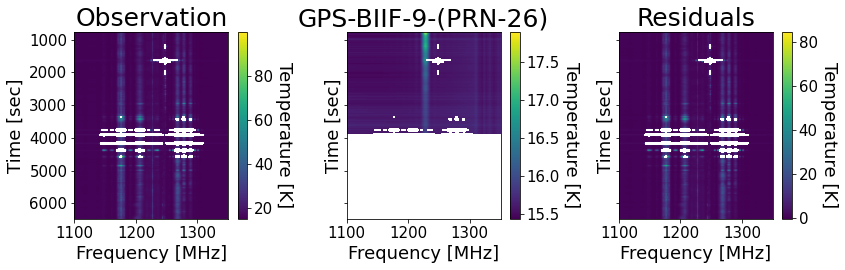

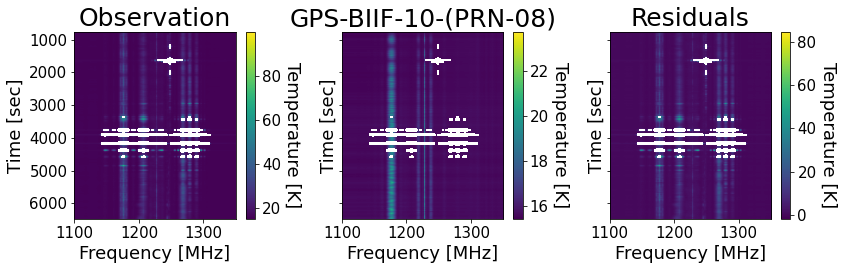

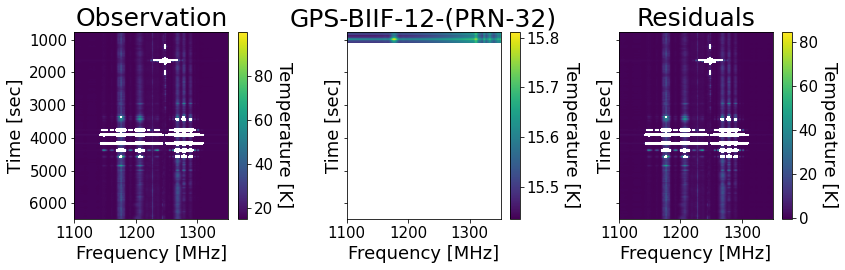

Satellites with only null alphas: ['GPS-BIIR-6-(PRN-14)', 'GPS-BIIR-10-(PRN-22)', 'GPS-BIIRM-2-(PRN-31)', 'GPS-BIIRM-6-(PRN-07)', 'GPS-BIIF-8-(PRN-03)']


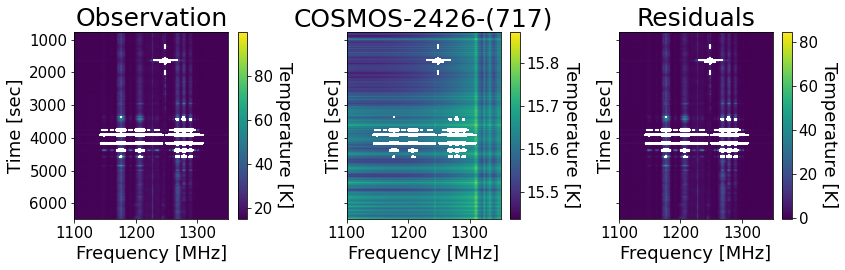

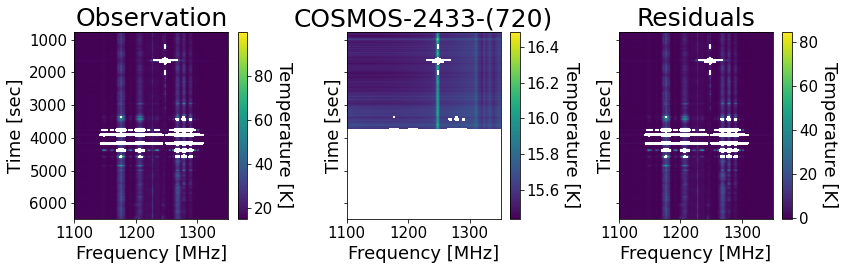

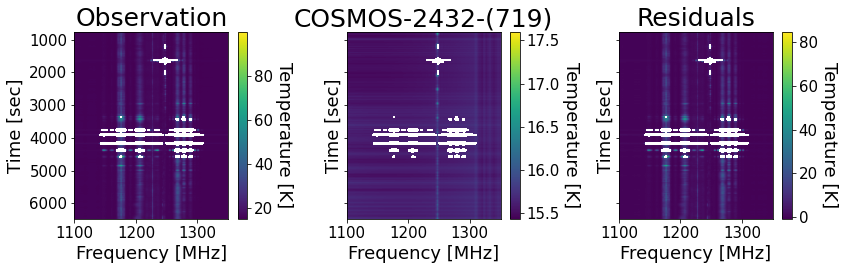

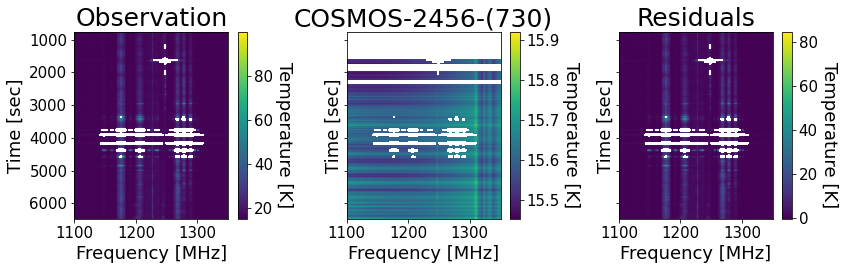

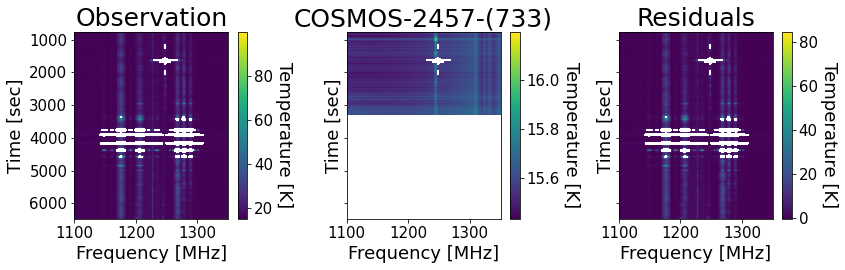

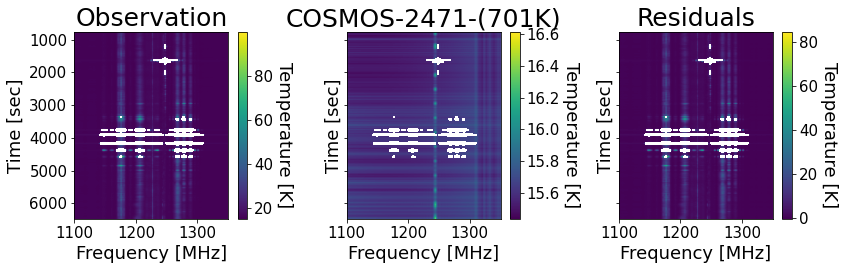

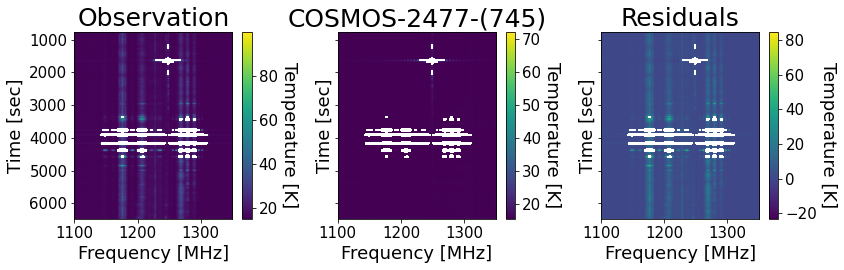

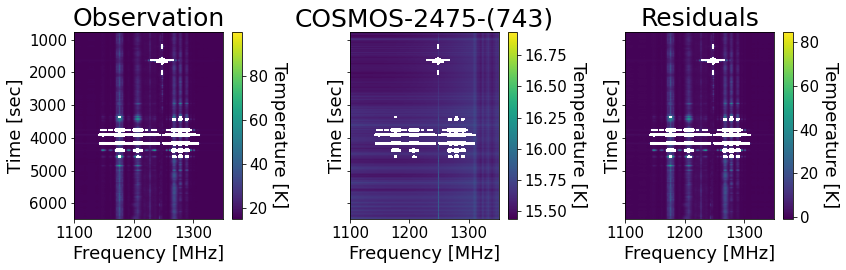

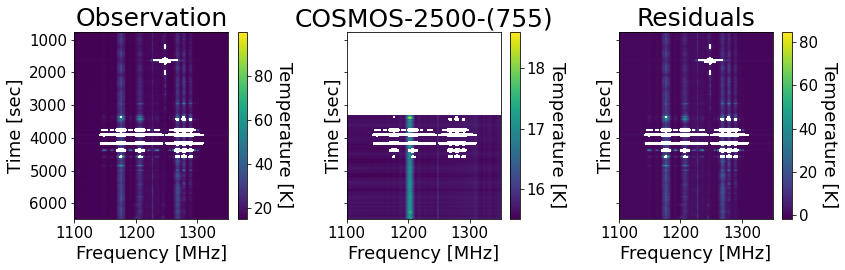

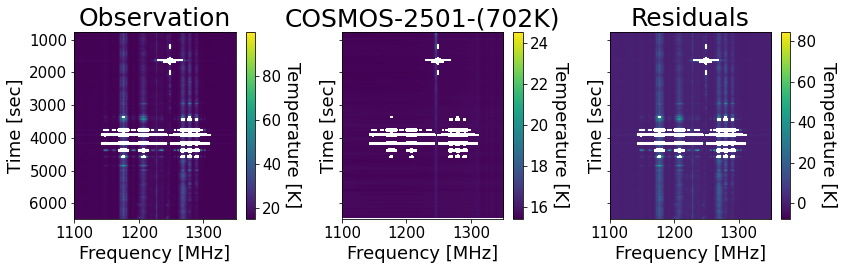

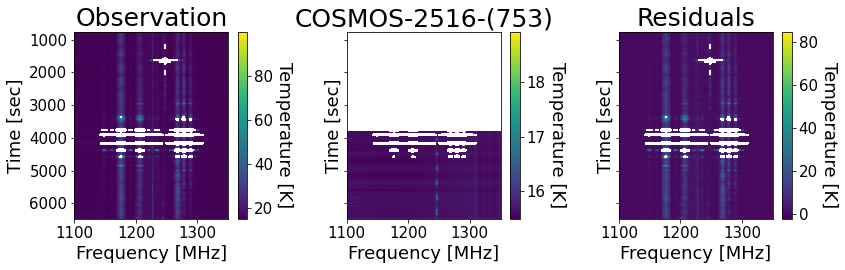

Satellites with only null alphas: []


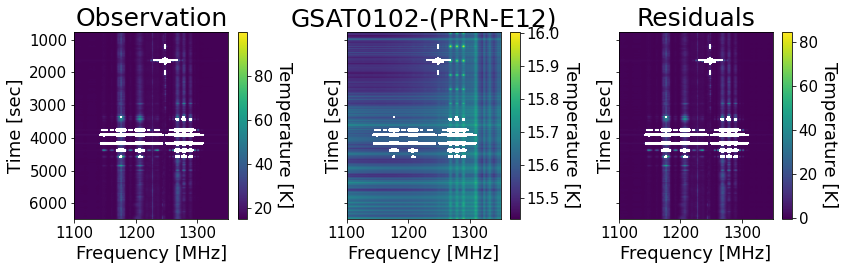

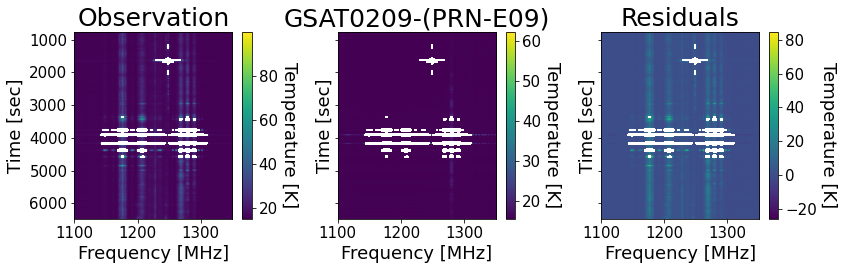

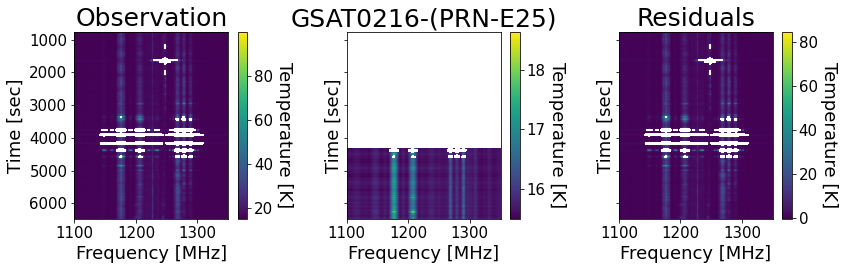

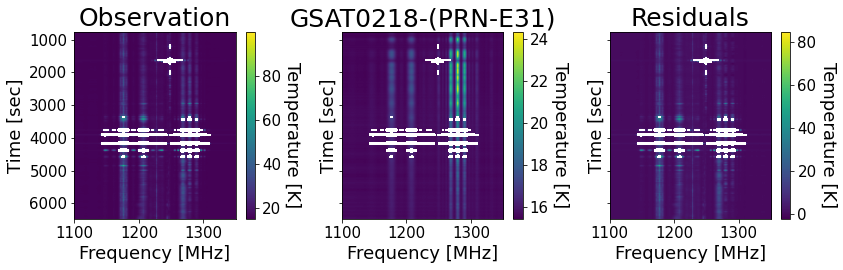

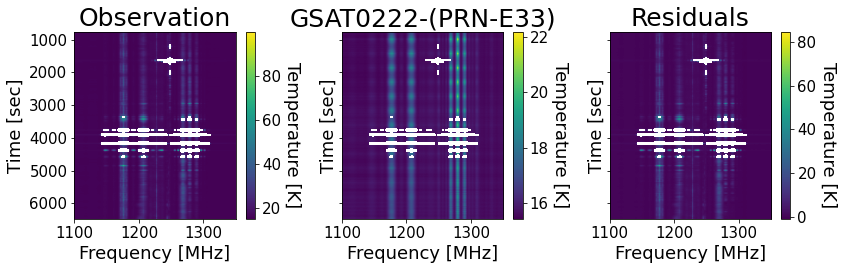

Satellites with only null alphas: ['GSAT0101-(PRN-E11)', 'GSAT0201-(PRN-E18)', 'GSAT0205-(PRN-E24)', 'GSAT0212-(PRN-E03)', 'GSAT0213-(PRN-E04)', 'GSAT0214-(PRN-E05)']


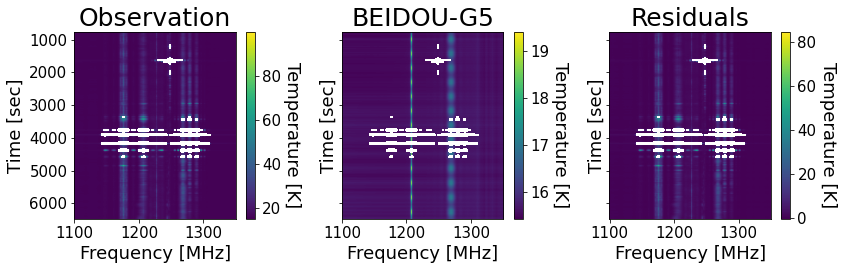

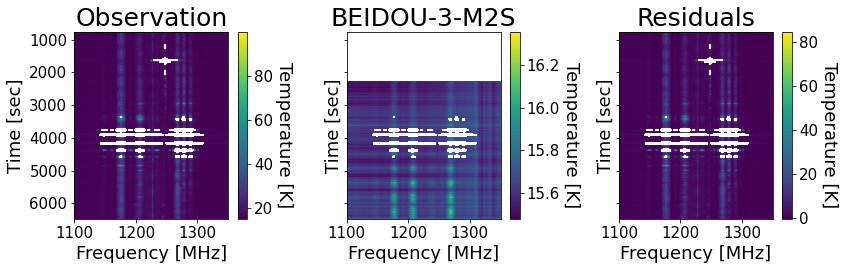

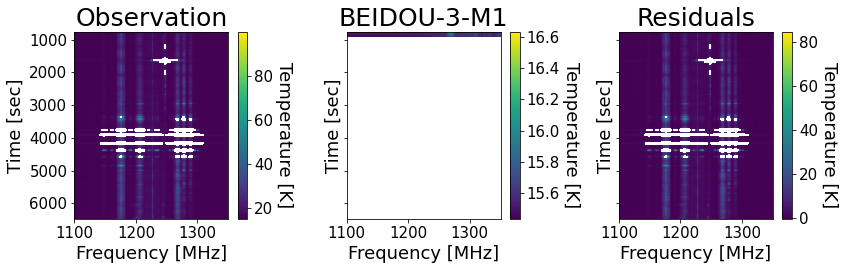

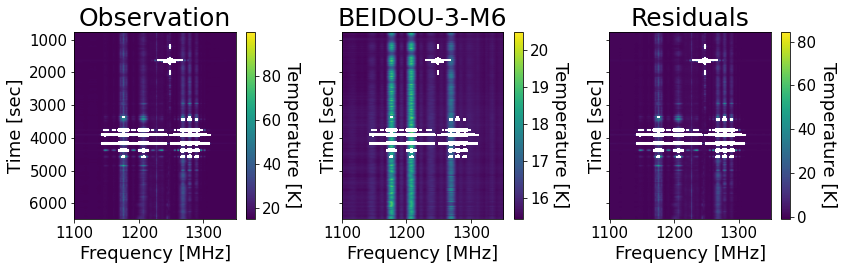

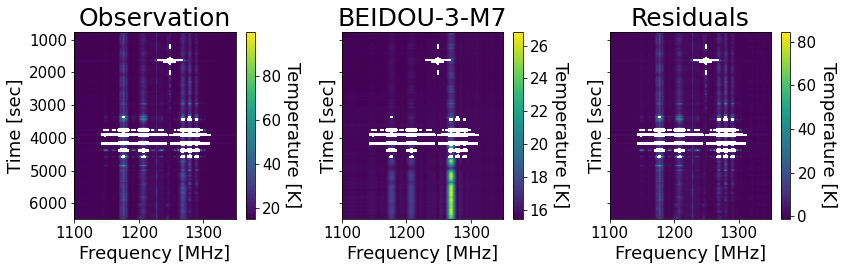

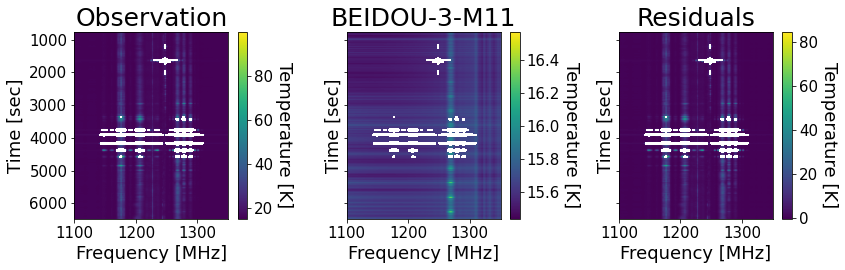

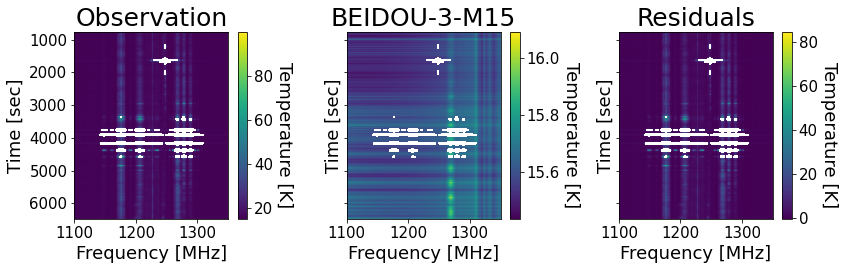

Satellites with only null alphas: ['BEIDOU-G3', 'BEIDOU-M4', 'BEIDOU-M6', 'BEIDOU-3-M5', 'BEIDOU-3-M17']


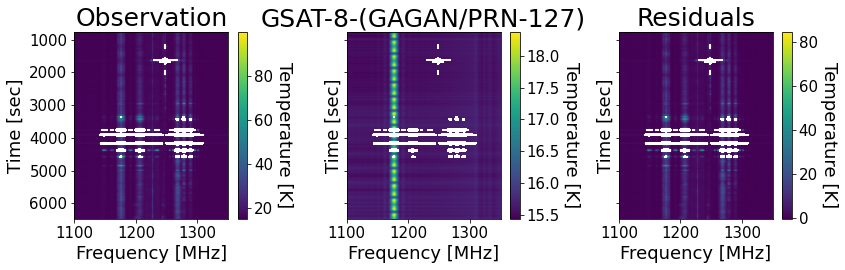

Satellites with only null alphas: ['AOR-E-(EGNOS/PRN-120)', 'IOR-W-(EGNOS/PRN-126)', 'SES-5-(EGNOS/PRN-136)', 'GSAT-10-(GAGAN/PRN-128)', 'LUCH-5B-(SDCM/PRN-125)', 'ASTRA-5B-(EGNOS/PRN-123)']


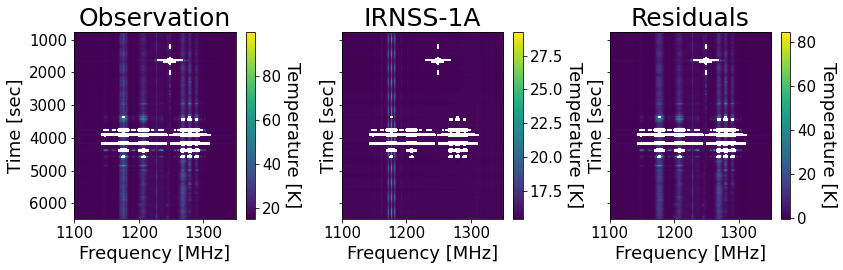

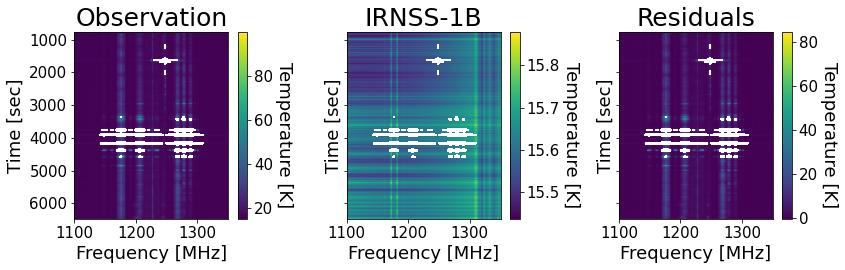

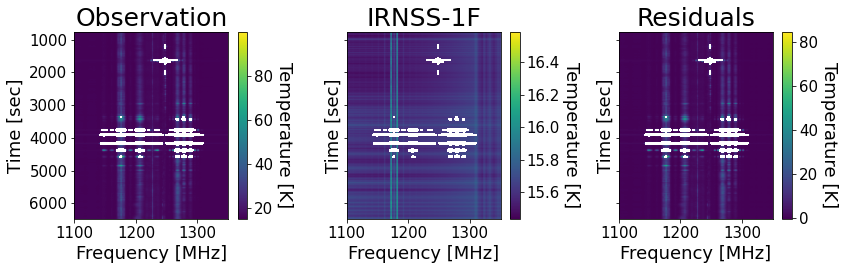

Satellites with only null alphas: ['IRNSS-1C', 'IRNSS-1I']


In [13]:
# plotting simulated signal 2d
for con in cons:
    plot_2d(con)
